## ML MODEL SUMMARIZER - CREDIT DATA EXPLORER WITH CLAUDE

### 02: Baseline Model Evaluation

==================================================================
#### SECTION 1: IMPORT PACKAGES & DATA LOADING
==================================================================

In [14]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, classification_report, roc_curve, roc_auc_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


In [15]:
df_model = pd.read_csv('../data/processed_loan_data.csv')

In [16]:
df_model = df_model.drop(['grade_encoded', 'sub_grade_encoded', 'last_pymnt_amnt_log_encoded'], axis=1) 

In [17]:
df_model['default_flag'].value_counts()

default_flag
0.0    1078712
1.0     269357
Name: count, dtype: int64

In [18]:
#set the seed for reproducibility across all random operations
seed = 42
np.random.seed(seed)
random.seed(42)

In [19]:
X = df_model.drop('default_flag', axis=1)  
y = df_model['default_flag']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=seed, stratify=y)

In [20]:
# test options for classification
num_folds = 10
scoring_1 = 'accuracy'
#scoring ='precision'
#scoring ='recall'
scoring_2 = 'roc_auc'

In [21]:
# spot check the algorithms
models = []
models.append(('LR', Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=seed))])))
models.append(('LDA', Pipeline([('scaler', StandardScaler()), ('model', LinearDiscriminantAnalysis())])))
models.append(('KNN', Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier())])))
models.append(('DT', DecisionTreeClassifier(random_state=seed)))
models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=seed)))
models.append(('XGB', XGBClassifier(eval_metric='logloss', random_state=seed)))
models.append(('LGBM', LGBMClassifier(random_state=seed, verbose=-1)))


In [22]:

results_acc = []
results_auc = []
names = []

for name, model in models:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=kfold,
        scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
        n_jobs=-1  # parallelize across CPU cores
    )
    acc = cv_results['test_accuracy']
    auc = cv_results['test_roc_auc']
    results_acc.append(acc)
    results_auc.append(auc)
    names.append(name)
    print(f"{name}: accuracy={acc.mean():.4f} ({acc.std():.4f}) | roc_auc={auc.mean():.4f} ({auc.std():.4f})")

LR: accuracy=0.8025 (0.0014) | roc_auc=0.7122 (0.0014)
LDA: accuracy=0.8012 (0.0012) | roc_auc=0.7113 (0.0015)
KNN: accuracy=0.7784 (0.0013) | roc_auc=0.6220 (0.0018)
DT: accuracy=0.7033 (0.0014) | roc_auc=0.5516 (0.0017)


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

RF: accuracy=0.8033 (0.0015) | roc_auc=0.7097 (0.0013)
XGB: accuracy=0.8044 (0.0014) | roc_auc=0.7252 (0.0009)
LGBM: accuracy=0.8048 (0.0013) | roc_auc=0.7251 (0.0012)


/var/folders/b6/z2j2f1js49s1rw1gfk04vyp40000gn/T/ipykernel_40375/2628468702.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(results_acc, labels=names)
/var/folders/b6/z2j2f1js49s1rw1gfk04vyp40000gn/T/ipykernel_40375/2628468702.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(results_auc, labels=names)


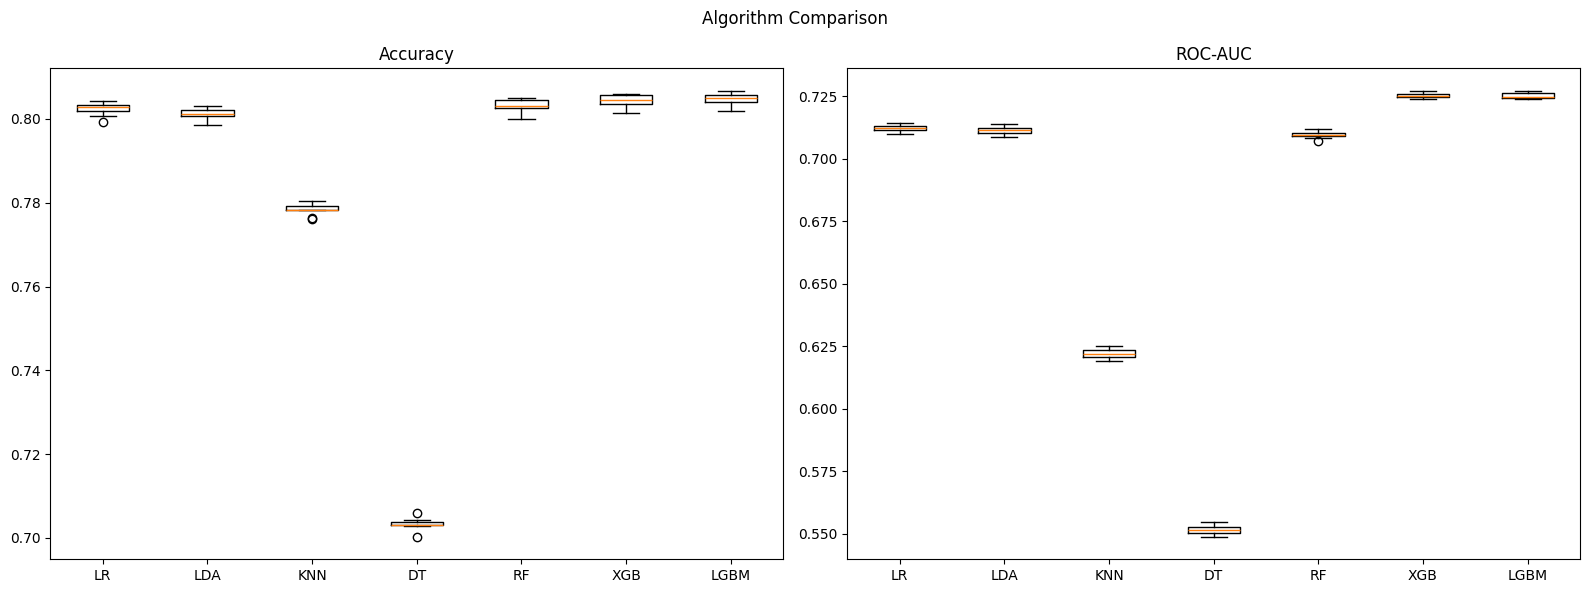

In [23]:
# compare algorithms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Algorithm Comparison')

axes[0].boxplot(results_acc, labels=names)
axes[0].set_title('Accuracy')

axes[1].boxplot(results_auc, labels=names)
axes[1].set_title('ROC-AUC')

plt.tight_layout()
plt.show()

In [24]:
acc_mean = []
acc_std = []
for i in results_acc:
    acc_mean.append(i.mean())
    acc_std.append(i.std())

In [25]:
auc_mean = []
auc_std = []
for i in results_auc:
    auc_mean.append(i.mean())
    auc_std.append(i.std())

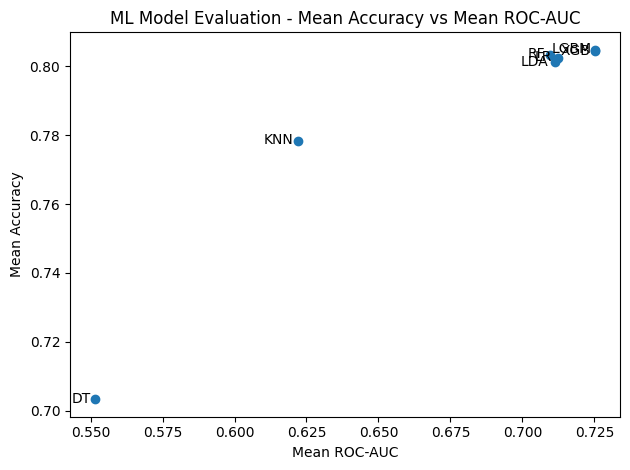

In [26]:
# compare algorithms

plt.title('ML Model Evaluation - Mean Accuracy vs Mean ROC-AUC')
plt.scatter(auc_mean, acc_mean)
for i, name in enumerate(names):
    if name == 'KNN' or name == 'XGB' or name == 'LDA':        
        plt.annotate(name, (auc_mean[i]-0.012, acc_mean[i]-0.001))
    elif name == 'LGBM':        
        plt.annotate(name, (auc_mean[i]-0.015, acc_mean[i]-0.001))
    else:
        plt.annotate(name, (auc_mean[i]-0.008, acc_mean[i]-0.001))

plt.xlabel('Mean ROC-AUC')
plt.ylabel('Mean Accuracy')


plt.tight_layout()
plt.show()